# Morfología matemática para limpieza de máscaras

**Duración estimada:** 85 minutos

## Objetivo

En este cuaderno vas a trabajar con una imagen real para entender cómo las operaciones morfológicas ayudan a limpiar máscaras binarias. La idea central es simple pero poderosa: antes de restaurar una imagen dañada, muchas veces tenemos que detectar con precisión dónde está el daño.

## Resultados de aprendizaje

Al final de este cuaderno vas a poder:

- explicar qué es un elemento estructurante o kernel;
- aplicar erosión y dilatación sobre una máscara binaria;
- usar apertura para borrar ruido blanco externo;
- usar clausura para tapar agujeros negros internos;
- argumentar por qué una máscara limpia mejora un pipeline de restauración.

## Relación con cuadernos anteriores

Este cuaderno continúa el trabajo de `006b - filtros de suavizado y reduccion de ruido.ipynb`. Allí limpiamos la imagen. Acá damos otro paso: limpiar la **máscara** que representa regiones de interés. En restauración, una mala máscara puede arruinar incluso un algoritmo muy bueno.


## 1. Concepto: una máscara no es una imagen cualquiera

Una máscara binaria tiene dos valores: una zona representa “esto me importa” y la otra representa “esto no me importa”. En muchos pipelines de restauración, segmentación o detección, esa decisión previa es crucial.

El problema es que las máscaras suelen salir sucias:

- con puntitos blancos aislados donde no deberían estar;
- con agujeros negros dentro de una forma que debería ser sólida;
- con bordes mal recortados o demasiado delgados.

Ahí entra la morfología matemática: un conjunto de operaciones que modifican la forma de las regiones usando una vecindad local.

[Pregunta para pensar]

Si una máscara representa una decisión sobre la imagen, ¿qué significa “limpiarla”? ¿La estamos corrigiendo o la estamos reinterpretando?


In [ ]:
from pathlib import Path
import urllib.request

import cv2
import numpy as np
import matplotlib.pyplot as plt


CARPETA_IMAGENES = Path("Imagenes")
CARPETA_IMAGENES.mkdir(exist_ok=True)

URL_IMAGEN = "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/notes.png"
RUTA_IMAGEN = CARPETA_IMAGENES / "notes.png"


def descargar_imagen_si_falta(url, ruta_local):
    '''Descarga una imagen de referencia solo si todavía no existe en disco.'''
    if ruta_local.exists():
        print(f"La imagen ya estaba disponible en: {ruta_local}")
        return

    print("La imagen no estaba en la carpeta local. La descargamos ahora.")
    urllib.request.urlretrieve(url, ruta_local)
    print(f"Imagen descargada en: {ruta_local}")


def preparar_eje_imagen(eje, imagen, titulo, mapa=None):
    '''Muestra una imagen con ejes visibles para leer coordenadas.'''
    eje.imshow(imagen, cmap=mapa)
    eje.set_title(titulo, loc="left", fontweight="bold")
    eje.set_xlabel("x (columnas)")
    eje.set_ylabel("y (filas)")

    if imagen.ndim == 2:
        alto, ancho = imagen.shape
    else:
        alto, ancho = imagen.shape[:2]

    paso_x = max(40, ancho // 6)
    paso_y = max(20, alto // 4)
    eje.set_xticks(np.arange(0, ancho + 1, paso_x))
    eje.set_yticks(np.arange(0, alto + 1, paso_y))
    eje.grid(color="white", alpha=0.25, linewidth=0.6)


def mostrar_varias_imagenes(imagenes, titulos, mapas=None, tamano=(16, 5)):
    '''Muestra varias imágenes lado a lado manteniendo ejes visibles.'''
    if mapas is None:
        mapas = [None] * len(imagenes)

    figura, ejes = plt.subplots(1, len(imagenes), figsize=tamano, constrained_layout=True)
    if len(imagenes) == 1:
        ejes = [ejes]

    for eje, imagen, titulo, mapa in zip(ejes, imagenes, titulos, mapas):
        preparar_eje_imagen(eje, imagen, titulo, mapa)

    plt.show()


def recortar_region(imagen, x_inicio, y_inicio, ancho, alto):
    '''Devuelve un recorte rectangular para observar detalle local.'''
    return imagen[y_inicio:y_inicio + alto, x_inicio:x_inicio + ancho]


def agregar_ruido_blanco_externo(mascara_binaria, cantidad=220, semilla=17):
    '''Agrega puntos blancos aislados fuera de la figura principal.'''
    generador = np.random.default_rng(semilla)
    mascara_con_ruido = mascara_binaria.copy()

    posiciones_fondo = np.argwhere(mascara_con_ruido == 0)
    indices_elegidos = generador.choice(len(posiciones_fondo), size=cantidad, replace=False)

    for indice in indices_elegidos:
        y, x = posiciones_fondo[indice]
        mascara_con_ruido[y, x] = 255

    return mascara_con_ruido


def agregar_agujeros_negros_internos(mascara_binaria, cantidad=45, radio=3, semilla=19):
    '''Abre pequeños agujeros negros dentro de las regiones blancas.'''
    generador = np.random.default_rng(semilla)
    mascara_con_agujeros = mascara_binaria.copy()

    posiciones_figura = np.argwhere(mascara_con_agujeros == 255)
    indices_elegidos = generador.choice(len(posiciones_figura), size=cantidad, replace=False)

    for indice in indices_elegidos:
        y, x = posiciones_figura[indice]
        cv2.circle(mascara_con_agujeros, (int(x), int(y)), radio, 0, -1)

    return mascara_con_agujeros


def contar_pixeles_blancos(imagen_binaria):
    '''Cuenta cuántos píxeles blancos hay en una máscara binaria.'''
    return int(np.count_nonzero(imagen_binaria == 255))


descargar_imagen_si_falta(URL_IMAGEN, RUTA_IMAGEN)


La imagen ya estaba disponible en: Imagenes\notes.png


## 2. Ejercicio guiado: partir de una imagen real y construir una máscara de trabajo

Vamos a usar una imagen real de partitura. Es un buen ejemplo porque tiene signos negros sobre un fondo claro y eso permite obtener una máscara binaria bastante limpia como punto de partida.

Primero vamos a abrir la imagen, pasarla a escala de grises y binarizarla. Para que la figura principal quede en blanco y el fondo en negro, usamos una inversión binaria.


Forma de la imagen en grises: (134, 1024)
Píxeles blancos en la máscara base: 15775


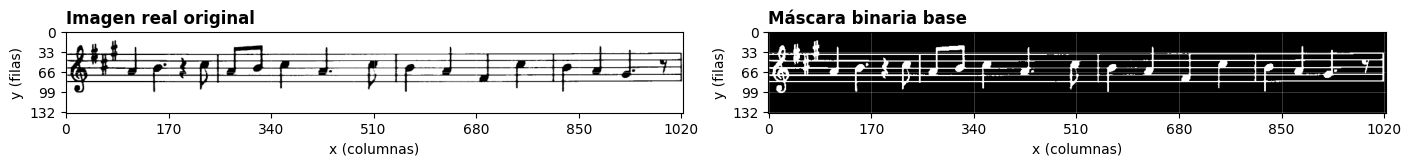

In [ ]:
imagen_gris = cv2.imread(str(RUTA_IMAGEN), cv2.IMREAD_GRAYSCALE)

_, mascara_base = cv2.threshold(
    imagen_gris,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU,
)

print("Forma de la imagen en grises:", imagen_gris.shape)
print("Píxeles blancos en la máscara base:", contar_pixeles_blancos(mascara_base))

mostrar_varias_imagenes(
    [imagen_gris, mascara_base],
    ["Imagen real original", "Máscara binaria base"],
    ["gray", "gray"],
    tamano=(14, 5),
)


**Qué observar**

- La partitura original tiene líneas y símbolos negros sobre un fondo blanco.
- En la máscara invertida, los elementos relevantes quedan en blanco.

**Qué conclusión podés sacar**

- Para muchas operaciones morfológicas conviene que la figura de interés sea el frente blanco sobre fondo negro.

**Qué limitación tiene este paso**

- No todas las imágenes reales binarizan tan fácilmente. En materiales patrimoniales puede haber sombras, manchas y textura de papel que compliquen mucho más la máscara inicial.


Ahora vamos a degradar esa máscara de manera controlada para simular dos problemas frecuentes:

- **ruido blanco externo**: puntitos aislados fuera de la forma principal;
- **agujeros negros internos**: pérdidas de continuidad dentro de la figura.

Esto nos va a permitir probar cada operación sobre una dificultad concreta.


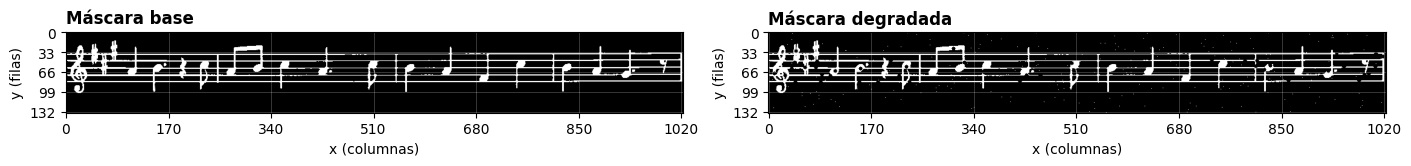

In [ ]:
mascara_con_ruido_externo = agregar_ruido_blanco_externo(mascara_base, cantidad=220, semilla=17)
mascara_degradada = agregar_agujeros_negros_internos(mascara_con_ruido_externo, cantidad=45, radio=3, semilla=19)

x_region = 120
y_region = 15
ancho_region = 180
alto_region = 70

mostrar_varias_imagenes(
    [mascara_base, mascara_degradada],
    ["Máscara base", "Máscara degradada"],
    ["gray", "gray"],
    tamano=(14, 5),
)


**Qué observar**

- Aparecen puntitos blancos sueltos en zonas del fondo.
- También aparecen pequeños huecos negros dentro de regiones que antes eran continuas.

**Qué conclusión se puede sacar**

- Una máscara puede fallar tanto por exceso como por defecto: puede agregar regiones falsas o perder continuidad interna.

**Qué limitación tiene este experimento**

- Acá controlamos exactamente dónde y cuánto degradamos. En una imagen histórica real, ese deterioro no suele ser tan regular ni tan fácil de describir.


## 3. Automatización con Python: erosión, dilatación, apertura y clausura

Vamos a trabajar con un **elemento estructurante** o **kernel**. Podés pensarlo como una pequeña ventana que recorre la imagen y decide cómo modificar la forma local.

En este cuaderno usamos un kernel elíptico porque suele producir resultados visualmente razonables en formas curvas y detalles finos.


In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

mascara_erosionada = cv2.erode(mascara_degradada, kernel, iterations=1)
mascara_dilatada = cv2.dilate(mascara_degradada, kernel, iterations=1)
mascara_apertura = cv2.morphologyEx(mascara_degradada, cv2.MORPH_OPEN, kernel)
mascara_clausura = cv2.morphologyEx(mascara_degradada, cv2.MORPH_CLOSE, kernel)

print("Kernel usado:")
print(kernel)


Kernel usado:
[[0 0 1 0 0]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [0 0 1 0 0]]


Primero vamos a mirar erosión y dilatación por separado. Son las dos operaciones básicas a partir de las cuales se construyen las demás.


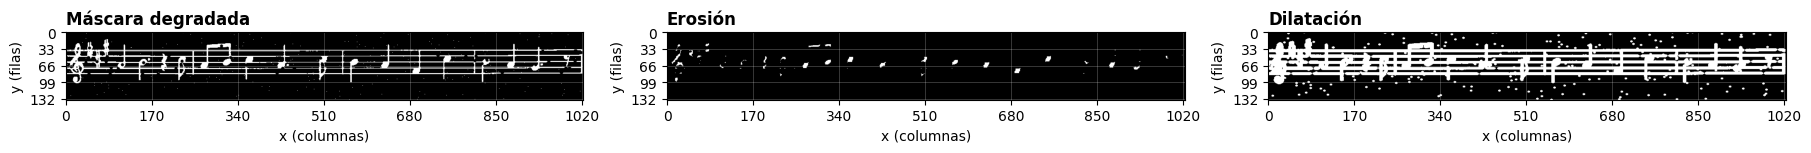

In [ ]:
mostrar_varias_imagenes(
    [mascara_degradada, mascara_erosionada, mascara_dilatada],
    ["Máscara degradada", "Erosión", "Dilatación"],
    ["gray", "gray", "gray"],
    tamano=(18, 5),
)


**Qué observar**

- La erosión achica las regiones blancas y puede borrar detalles muy finos.
- La dilatación agranda las regiones blancas y puede tapar pequeñas interrupciones.

**Qué conclusión podés sacar**

- Cada operación resuelve un problema, pero empeora otro. Por eso rara vez alcanza con usar solo una.

**Qué limitación tiene este paso**

- Si el kernel es demasiado grande, el cambio de forma deja de ser corrección y pasa a ser deformación fuerte.


Ahora vamos a mirar las dos combinaciones más importantes:

- **Apertura = erosión + dilatación**: suele servir para borrar ruido blanco externo.
- **Clausura = dilatación + erosión**: suele servir para tapar agujeros negros internos.


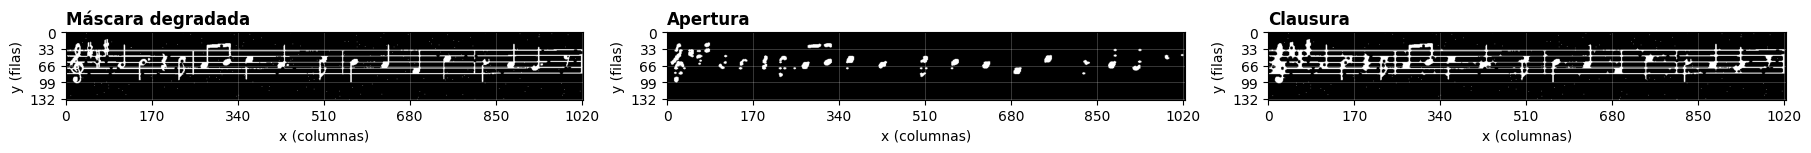

In [ ]:
mostrar_varias_imagenes(
    [mascara_degradada, mascara_apertura, mascara_clausura],
    ["Máscara degradada", "Apertura", "Clausura"],
    ["gray", "gray", "gray"],
    tamano=(18, 5),
)


**Qué observar**

- La apertura reduce muchos puntos blancos aislados del fondo.
- La clausura mejora continuidad dentro de algunas formas y líneas interrumpidas.

**Qué conclusión se puede sacar**

- La apertura y la clausura no compiten: resuelven problemas distintos.

**Qué limitación tiene lo que acabamos de ver**

- Si la máscara tiene a la vez mucho ruido externo y muchos huecos internos, quizás convenga encadenar operaciones y no quedarse con una sola.


## 4. Reflexión guiada

[Pregunta para pensar]

El kernel define qué tan grande debe ser una imperfección para que el algoritmo la trate como ruido y no como parte significativa de la forma.

- Si cambiás un kernel de `5x5` por uno de `11x11`, ¿qué detalles dejás de respetar?
- ¿Dónde está el límite entre “limpiar” una máscara y simplificarla demasiado?
- En una foto antigua, ¿qué podría pasar si el agujero o la grieta que querés detectar tiene el mismo tamaño que el detalle gráfico legítimo?


## 5. Ejemplo práctico: mirar una región local y medir el efecto

A veces una vista global no alcanza. Vamos a recortar una región donde haya líneas y símbolos de la partitura para comparar mejor cómo cambia la forma local.


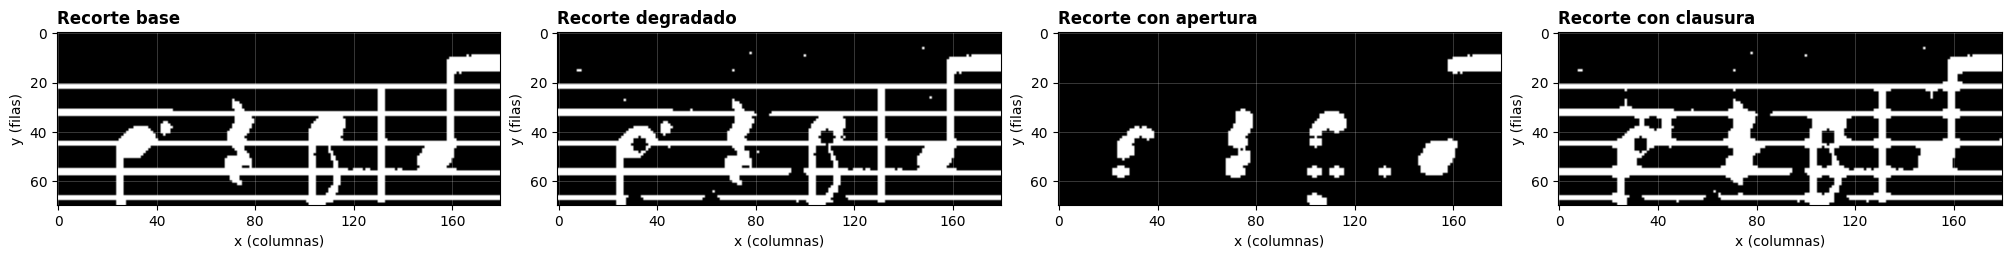

Píxeles blancos en la máscara base: 15775
Píxeles blancos en la máscara degradada: 15239
Píxeles blancos después de apertura: 4320
Píxeles blancos después de clausura: 16733


In [ ]:
recorte_base = recortar_region(mascara_base, x_region, y_region, ancho_region, alto_region)
recorte_degradado = recortar_region(mascara_degradada, x_region, y_region, ancho_region, alto_region)
recorte_apertura = recortar_region(mascara_apertura, x_region, y_region, ancho_region, alto_region)
recorte_clausura = recortar_region(mascara_clausura, x_region, y_region, ancho_region, alto_region)

mostrar_varias_imagenes(
    [recorte_base, recorte_degradado, recorte_apertura, recorte_clausura],
    ["Recorte base", "Recorte degradado", "Recorte con apertura", "Recorte con clausura"],
    ["gray", "gray", "gray", "gray"],
    tamano=(20, 5),
)

print("Píxeles blancos en la máscara base:", contar_pixeles_blancos(mascara_base))
print("Píxeles blancos en la máscara degradada:", contar_pixeles_blancos(mascara_degradada))
print("Píxeles blancos después de apertura:", contar_pixeles_blancos(mascara_apertura))
print("Píxeles blancos después de clausura:", contar_pixeles_blancos(mascara_clausura))


**Qué observar**

- En el recorte se vuelve más evidente qué ruido externo desaparece y qué huecos internos persisten o se corrigen.
- El conteo de píxeles blancos no reemplaza la inspección visual, pero ayuda a cuantificar el cambio.

**Qué conclusión podés sacar**

- La limpieza de una máscara es una operación geométrica local, no solo una mejora “estética”. Cambia el área y la conectividad de las regiones.

**Qué limitación tiene este ejemplo**

- Dos máscaras pueden tener un conteo parecido de píxeles blancos y, sin embargo, una estar mucho mejor estructurada que la otra.


## 6. Limitaciones y próximos pasos

La morfología matemática es muy útil, pero no es una receta automática.

- Si el kernel es muy chico, la limpieza puede ser insuficiente.
- Si el kernel es muy grande, podés destruir trazos legítimos.
- Si la máscara inicial es mala, la morfología no la convierte mágicamente en una segmentación perfecta.

En restauración, una máscara bien depurada puede marcar rayones, faltantes o manchas antes de pasar a un algoritmo de reparación.

## Actividad breve

Probá tres variantes y comparalas:

1. apertura con kernel `3x3`;
2. apertura con kernel `7x7`;
3. clausura con kernel `7x7`.

Después respondé: **¿en qué momento el intento de limpiar la máscara empieza a deformar demasiado la forma original?**

## Cierre

En este cuaderno trabajaste con el problema de limpiar máscaras sobre una imagen real. En el siguiente paso vamos a usar una máscara de daño para intentar reconstruir regiones faltantes mediante **inpainting**, que es una de las técnicas centrales para restauración digital.
